<a href="https://colab.research.google.com/github/chw1230/LLMProgramming/blob/main/Word2Vec/%EA%B3%BC%EC%A0%9C/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import torch
device = torch.device(
"cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

Device: cuda


In [44]:
sentences = [
"king is a royal man",
"queen is a royal woman",
"king rules the kingdom",
"queen rules the kingdom",
"king lives in the palace",
"queen lives in the palace",
"prince is a young man",
"princess is a young woman",
"prince lives in the palace",
"princess lives in the palace",
"man is a male person",
"woman is a female person",
"boy is a young male",
"girl is a young female",
"dog is an animal",
"cat is an animal",
"dog is a pet",
"cat is a pet",
"puppy is a young dog",
"kitten is a young cat",
"apple is a fruit",
"banana is a fruit",
"orange is a fruit",
"apple is sweet",
"banana is sweet",
"orange is sweet",
"car is a vehicle",
"bus is a vehicle",
"truck is a vehicle",
"car moves on road",
"bus moves on road",
"truck moves on road",
]


# Tokenize - 토큰화
corpus = []

for sentence in sentences:
    tokens = sentence.lower().split()
    corpus.append(tokens)

for tokens in corpus[:5]:
    print(tokens)


# Build vocabulary - 단어장 40개 생성 -> 40개의 고유 단어를 모아서 각각 ID 부여
words = []
for sentence in corpus:
   words.extend(sentence)

# 단어장 생성
vocab = sorted(set(words))

# 단어에 ID 부여
word_to_id = {
    word: i
    for i, word in enumerate(vocab)
}

id_to_word = {
    i: word
    for word, i in word_to_id.items()
}
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)
print(word_to_id)

# Generate Skip-gram Training Pair
# corpus 순회하면서 중심, 주변 학습 데이터 쌍 생성 / window 크기 2로 설정
def generate_skipgram_pairs(corpus, window=2):
    pairs = []

    for sentence in corpus:

        for i in range(len(sentence)):
            center_word = sentence[i] # 중심 단어
            start = max(0, i - window)
            end = min(len(sentence),i + window + 1)

            for j in range(start, end):
                if i == j:
                    continue

                context_word = sentence[j]

                center_id = word_to_id[center_word]
                context_id = word_to_id[context_word]
                pairs.append((center_id, context_id))
    return pairs

['king', 'is', 'a', 'royal', 'man']
['queen', 'is', 'a', 'royal', 'woman']
['king', 'rules', 'the', 'kingdom']
['queen', 'rules', 'the', 'kingdom']
['king', 'lives', 'in', 'the', 'palace']
Vocabulary size: 40
{'a': 0, 'an': 1, 'animal': 2, 'apple': 3, 'banana': 4, 'boy': 5, 'bus': 6, 'car': 7, 'cat': 8, 'dog': 9, 'female': 10, 'fruit': 11, 'girl': 12, 'in': 13, 'is': 14, 'king': 15, 'kingdom': 16, 'kitten': 17, 'lives': 18, 'male': 19, 'man': 20, 'moves': 21, 'on': 22, 'orange': 23, 'palace': 24, 'person': 25, 'pet': 26, 'prince': 27, 'princess': 28, 'puppy': 29, 'queen': 30, 'road': 31, 'royal': 32, 'rules': 33, 'sweet': 34, 'the': 35, 'truck': 36, 'vehicle': 37, 'woman': 38, 'young': 39}


1. Train the model with two different window sizes

• window = 1


• window = 4


Then compare the top-5 similar words for: words = ["king", "queen",
"dog", "apple", "car"]
Briefly explain how the context window changes the results.

In [45]:
pairs1 = generate_skipgram_pairs(corpus,window=1)
pairs4 = generate_skipgram_pairs(corpus,window=4)

print("Number of training pairs1:", len(pairs1))
print("Number of training pairs4:", len(pairs4))

# 페어 출력해서 보기!
print("pair1")
for center_id, context_id in pairs1[:20]:
    print(id_to_word[center_id], "->", id_to_word[context_id])

print("\n\npair4")
for center_id, context_id in pairs4[:20]:
    print(id_to_word[center_id], "->", id_to_word[context_id])

Number of training pairs1: 214
Number of training pairs4: 478
pair1
king -> is
is -> king
is -> a
a -> is
a -> royal
royal -> a
royal -> man
man -> royal
queen -> is
is -> queen
is -> a
a -> is
a -> royal
royal -> a
royal -> woman
woman -> royal
king -> rules
rules -> king
rules -> the
the -> rules


pair4
king -> is
king -> a
king -> royal
king -> man
is -> king
is -> a
is -> royal
is -> man
a -> king
a -> is
a -> royal
a -> man
royal -> king
royal -> is
royal -> a
royal -> man
man -> king
man -> is
man -> a
man -> royal


In [46]:
# win = 1
center_words1 = torch.tensor(
    [pair[0] for pair in pairs1],
    dtype=torch.long
)

context_words1 = torch.tensor(
    [pair[1] for pair in pairs1],
    dtype=torch.long
)

print(center_words1.shape)
print(context_words1.shape)


# win = 4
center_words4 = torch.tensor(
    [pair[0] for pair in pairs4],
    dtype=torch.long
)

context_words4 = torch.tensor(
    [pair[1] for pair in pairs4],
    dtype=torch.long
)

print(center_words4.shape)
print(context_words4.shape)


torch.Size([214])
torch.Size([214])
torch.Size([478])
torch.Size([478])


In [47]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# win = 1
# 중심, 주변으로 묶기
dataset1 = TensorDataset(center_words1,context_words1)

# 64개의 배치 사이즈로 제공
loader1 = DataLoader(dataset1,batch_size=64,shuffle=True)

# win = 4
# 중심, 주변으로 묶기
dataset4 = TensorDataset(center_words4,context_words4)

# 64개의 배치 사이즈로 제공
loader4 = DataLoader(dataset4,batch_size=64,shuffle=True)

In [48]:
# Skip-gram 신경망 생성
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__( self, vocab_size, embedding_dim ):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_words):

        # 중심 단어 ID를 embedding vector로 바꾸기
        embedded = self.embedding(center_words)
        # 밑LLM에서 배운 것 처럼 특정 단어를 통과 시키면 해당 단어에 대한 embedding_dim차원 백터가 나옴!

        # embedding(백터를) -> vocabulary logits(40개의 점수 결과가 나온당)
        logits = self.output(embedded)

        return logits

In [49]:
# win 1을 위한 model 생성
embedding_dim = 50
model1 = SkipGramModel(vocab_size,embedding_dim)
model1 = model1.to(device)
print(model1)

# win 4을 위한 model 생성
embedding_dim = 50
model4 = SkipGramModel(vocab_size,embedding_dim)
model4 = model4.to(device)
print(model4)

SkipGramModel(
  (embedding): Embedding(40, 50)
  (output): Linear(in_features=50, out_features=40, bias=True)
)
SkipGramModel(
  (embedding): Embedding(40, 50)
  (output): Linear(in_features=50, out_features=40, bias=True)
)


In [50]:
# Loss & optimizer
criterion = nn.CrossEntropyLoss()

optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.01)  # model1 전용
optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.01)  # model4 전용

In [51]:
# Word2Vec 훈련

# 200번
epochs = 200

print("window = 1")
for epoch in range(epochs):
    total_loss = 0

    for centers, contexts in loader1:
        centers = centers.to(device)
        contexts = contexts.to(device)

        # 그레디언트 초기화
        optimizer1.zero_grad()

        logits = model1(centers)

        loss = criterion(logits,contexts)

        loss.backward()

        optimizer1.step()

        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        average_loss = (total_loss / len(loader1))
        print(
            f"Epoch {epoch+1:3d}, "
            f"Loss: {average_loss:.4f}")

print("window = 4")
for epoch in range(epochs):
    total_loss = 0

    for centers, contexts in loader4:
        centers = centers.to(device)
        contexts = contexts.to(device)

        # 그레디언트 초기화
        optimizer4.zero_grad()

        logits = model4(centers)

        loss = criterion(logits,contexts)

        loss.backward()

        optimizer4.step()

        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        average_loss = (total_loss / len(loader4))
        print(
            f"Epoch {epoch+1:3d}, "
            f"Loss: {average_loss:.4f}")

window = 1
Epoch  20, Loss: 1.3876
Epoch  40, Loss: 1.3307
Epoch  60, Loss: 1.3482
Epoch  80, Loss: 1.3747
Epoch 100, Loss: 1.3645
Epoch 120, Loss: 1.3297
Epoch 140, Loss: 1.3143
Epoch 160, Loss: 1.2673
Epoch 180, Loss: 1.2900
Epoch 200, Loss: 1.3134
window = 4
Epoch  20, Loss: 2.2100
Epoch  40, Loss: 2.1763
Epoch  60, Loss: 2.1667
Epoch  80, Loss: 2.1535
Epoch 100, Loss: 2.1676
Epoch 120, Loss: 2.1614
Epoch 140, Loss: 2.1820
Epoch 160, Loss: 2.1785
Epoch 180, Loss: 2.1596
Epoch 200, Loss: 2.1834


In [52]:
print(1)
embeddings1 = model1.embedding.weight
print(embeddings1.shape)
print(embeddings1.device)

print(4)
embeddings4 = model4.embedding.weight
print(embeddings4.shape)
print(embeddings4.device)

king_id = word_to_id["king"]
king_vector1 = embeddings1[king_id]
king_vector4 = embeddings4[king_id]

# king에 해당하는 임베딩 백터 출력
print(king_vector1)
print(king_vector4)

1
torch.Size([40, 50])
cuda:0
4
torch.Size([40, 50])
cuda:0
tensor([-1.7350, -0.6588,  0.3367,  0.6834,  0.4786, -1.2494, -1.3314,  0.4196,
         0.3135,  1.6493, -0.7512,  0.2849,  0.4289,  1.0716, -1.9180,  1.2805,
        -1.7002, -1.5140, -0.3451,  0.6364,  1.2140,  1.0615,  0.8624,  0.3214,
         0.1977,  0.7716,  1.7109, -1.4008,  1.9214,  0.0330, -0.7994, -0.2561,
         1.7810,  1.2067, -0.3196, -0.5777, -0.0310,  0.8225,  2.1929,  1.3124,
         0.0060, -0.7576, -0.4722, -0.6366,  0.8516, -0.0125, -0.5059,  0.5024,
         0.7814, -0.7655], device='cuda:0', grad_fn=<SelectBackward0>)
tensor([ 0.6832, -0.5606,  0.0978,  0.6954, -0.1396, -1.4431,  1.2509, -0.8492,
         0.5418, -0.1178,  0.5184, -0.6721, -1.0163, -1.2128, -1.9790, -0.7478,
        -0.7132,  1.7501, -0.1854, -1.4268, -0.3895,  0.2580, -1.0554,  0.1247,
        -0.9683, -1.2946,  0.2290,  0.4134, -0.2718, -0.1724, -1.9314, -1.7899,
        -0.6356,  0.6177, -0.6806,  0.3404,  0.6460, -0.9022,  0.6162

In [53]:
import torch.nn.functional as F

# 가장 비슷한 단어 top-k 찾기
def most_similar(embeddings, word, top_k=5):
    # 백터의 크기를 1로 만들기
    normalized = F.normalize(embeddings, p=2, dim=1)
    target = normalized[word_to_id[word]]

    # 단어장의 단어 40개와 COS 유사도를 한 번에 계산하기
    similarities = torch.matmul(normalized, target)

    # 유사도 큰 순
    values, indices = torch.topk(similarities, k=top_k + 1)

    results = []
    for score, idx in zip(values.tolist(), indices.tolist()):
        candidate = id_to_word[idx]

        if candidate != word:
            results.append((candidate, round(score, 3)))

        if len(results) == top_k:
            break
    return results

# window 1 vs window 4 비교하기
words = ["king", "queen", "dog", "apple", "car"]
for w in words:
    print(f"[{w}]")
    print("  window=1:", most_similar(embeddings1, w))
    print("  window=4:", most_similar(embeddings4, w))
    print()

[king]
  window=1: [('an', 0.422), ('puppy', 0.327), ('princess', 0.305), ('boy', 0.251), ('apple', 0.236)]
  window=4: [('queen', 0.386), ('the', 0.266), ('in', 0.229), ('lives', 0.207), ('pet', 0.188)]

[queen]
  window=1: [('sweet', 0.295), ('prince', 0.275), ('an', 0.235), ('puppy', 0.233), ('the', 0.222)]
  window=4: [('king', 0.386), ('kingdom', 0.305), ('in', 0.242), ('woman', 0.212), ('orange', 0.203)]

[dog]
  window=1: [('man', 0.397), ('girl', 0.38), ('orange', 0.324), ('cat', 0.308), ('princess', 0.255)]
  window=4: [('cat', 0.416), ('man', 0.309), ('girl', 0.252), ('royal', 0.215), ('princess', 0.211)]

[apple]
  window=1: [('banana', 0.423), ('boy', 0.397), ('an', 0.396), ('orange', 0.363), ('sweet', 0.309)]
  window=4: [('orange', 0.47), ('banana', 0.417), ('fruit', 0.354), ('vehicle', 0.32), ('a', 0.24)]

[car]
  window=1: [('bus', 0.434), ('truck', 0.431), ('pet', 0.24), ('orange', 0.21), ('sweet', 0.205)]
  window=4: [('truck', 0.328), ('bus', 0.294), ('sweet', 0.231)

2. Compute cosine similarity for selected pairs



For example:

king - queen

dog - cat

apple - banana

car - bus

king - banana

dog - car



Report the similarity values and identify which pairs are most/least
similar.

In [54]:
import torch.nn.functional as F
def similarity(w1,w2):
    id1 = word_to_id[w1]
    id2 = word_to_id[w2]
    # win = 4 모델로
    v1 = embeddings4[id1]
    v2 = embeddings4[id2]

    score = F.cosine_similarity(v1.unsqueeze(0),v2.unsqueeze(0))
    return score.item()

# win 4 로 진행하기!
print("king - queen:",
similarity("king", "queen"))

print("dog - cat:",
similarity("dog", "cat"))

print("apple - banana:",
similarity("apple", "banana"))

print("dog - car:",
similarity("dog", "car"))

print("king - banana:",
similarity("king", "banana"))

print("car - bus:",
similarity("car", "bus"))

king - queen: 0.38627463579177856
dog - cat: 0.4161101281642914
apple - banana: 0.4170417785644531
dog - car: 0.07395602762699127
king - banana: 0.1127326488494873
car - bus: 0.294452965259552


3. Create a 2-D PCA visualization

Plot at least 12 selected words, such as:

words = [ "king", "queen", "man", "woman", "apple", "banana", "car", "bus", "prince", "princess","dog", "cat"]

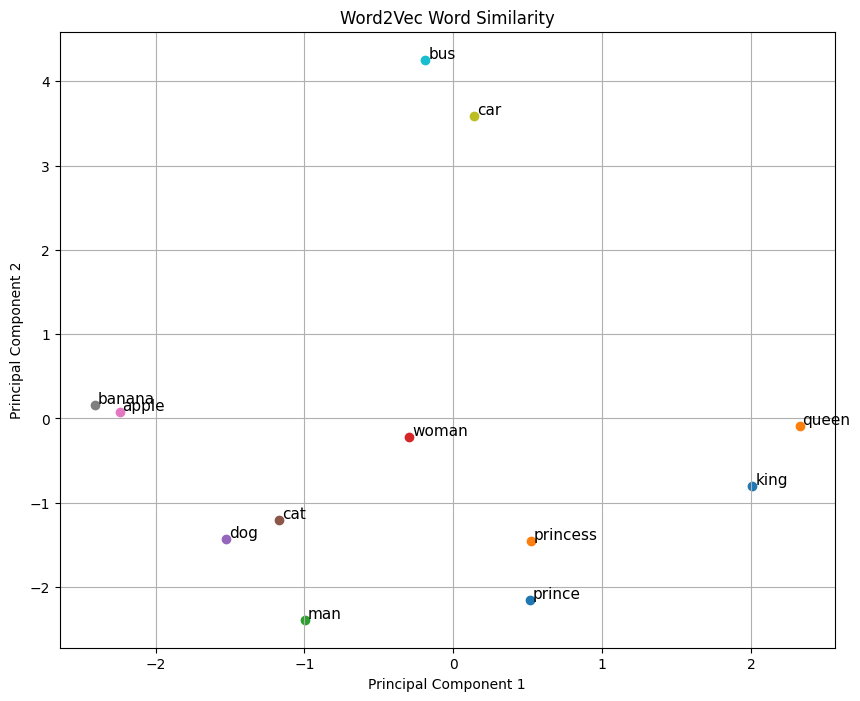

In [55]:
# Word2Vec Embedding PCA 시각화
embedding_cpu = (
    model4.embedding.weight
    .detach()
    .cpu()
    .numpy()
)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(
    embedding_cpu
)

words = [
    "king", "queen", "man", "woman", "dog", "cat",
    "apple", "banana", "car", "bus", "prince", "princess"
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for word in words:
    i = word_to_id[word]
    x = vectors_2d[i, 0]
    y = vectors_2d[i, 1]

    plt.scatter(x, y)

    plt.text(
        x + 0.02,
        y + 0.02,
        word,
        fontsize=11
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Word2Vec Word Similarity")
plt.grid(True)
plt.show()

# 의미가 비슷한 단어들이 모인 것을 볼 수 있음!
# 왕과 관련된 단어들이 우측에 모이고, 과일은 과일끼리, 성별끼리 모인 것을 볼 수 있음!

# 4. Add 5–10 new training sentences

For example, add a new context for "apple" :

apple company makes computer
apple makes smartphone
apple company makes phone
등 2개더 추가하기!

Retrain the model and compare most_similar("apple") before and after adding the new sentences.

The main learning objective is :

Word embeddings are learned from context, and changing the training context changes the geometry of the embedding space.

In [56]:
# 문장 추가 전
before = most_similar(embeddings4, "apple")

# 문장 추가 부터 쭉 진행
new_sentences = ["apple company makes computer", "apple makes smartphone", "apple company makes phone", "apple sells ipad", "apple designs ipad"]
sentencesNew = sentences + new_sentences

# Tokenize - 토큰화
corpus = []

for sentence in sentencesNew:
    tokens = sentence.lower().split()
    corpus.append(tokens)

for tokens in corpus[:5]:
    print(tokens)


# Build vocabulary - 단어장 새롭게 생성 -> 고유 단어를 모아서 각각 ID 부여
words = []
for sentence in corpus:
   words.extend(sentence)

# 단어장 생성
vocab = sorted(set(words))

# 단어에 ID 부여
word_to_id = {
    word: i
    for i, word in enumerate(vocab)
}

id_to_word = {
    i: word
    for word, i in word_to_id.items()
}
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)
print(word_to_id)

# Generate Skip-gram Training Pair
# corpus 순회하면서 중심, 주변 학습 데이터 쌍 생성 / window 크기 2로 설정
def generate_skipgram_pairs(corpus, window=4):
    pairs = []

    for sentence in corpus:

        for i in range(len(sentence)):
            center_word = sentence[i] # 중심 단어
            start = max(0, i - window)
            end = min(len(sentence),i + window + 1)

            for j in range(start, end):
                if i == j:
                    continue

                context_word = sentence[j]

                center_id = word_to_id[center_word]
                context_id = word_to_id[context_word]
                pairs.append((center_id, context_id))
    return pairs

# pair 생성하기
pairs4 = generate_skipgram_pairs(corpus,window=4)

print("Number of training pairs4:", len(pairs4))

print("\n\npair4")
for center_id, context_id in pairs4[:20]:
    print(id_to_word[center_id], "->", id_to_word[context_id])

# win = 4 , tensor
center_words4 = torch.tensor(
    [pair[0] for pair in pairs4],
    dtype=torch.long
)

context_words4 = torch.tensor(
    [pair[1] for pair in pairs4],
    dtype=torch.long
)

print(center_words4.shape)
print(context_words4.shape)

# dataset과 dataload
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# win = 4
# 중심, 주변으로 묶기
dataset4 = TensorDataset(center_words4,context_words4)

# 64개의 배치 사이즈로 제공
loader4 = DataLoader(dataset4,batch_size=64,shuffle=True)

# 새로움 모델!
# Skip-gram 신경망 생성
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__( self, vocab_size, embedding_dim ):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_words):

        # 중심 단어 ID를 embedding vector로 바꾸기
        embedded = self.embedding(center_words)
        # 밑LLM에서 배운 것 처럼 특정 단어를 통과 시키면 해당 단어에 대한 embedding_dim차원 백터가 나옴!

        # embedding(백터를) -> vocabulary logits(40개의 점수 결과가 나온당)
        logits = self.output(embedded)

        return logits
# win 4을 위한 model 생성
embedding_dim = 50
model4 = SkipGramModel(vocab_size,embedding_dim)
model4 = model4.to(device)
print(model4 ,"\n\n")

# Loss & optimizer
optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.01)

# Word2Vec 훈련

# 200번
epochs = 200

print("window = 4")
for epoch in range(epochs):
    total_loss = 0

    for centers, contexts in loader4:
        centers = centers.to(device)
        contexts = contexts.to(device)

        # 그레디언트 초기화
        optimizer4.zero_grad()

        logits = model4(centers)

        loss = criterion(logits,contexts)

        loss.backward()

        optimizer4.step()

        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        average_loss = (total_loss / len(loader4))
        print(
            f"Epoch {epoch+1:3d}, "
            f"Loss: {average_loss:.4f}")

['king', 'is', 'a', 'royal', 'man']
['queen', 'is', 'a', 'royal', 'woman']
['king', 'rules', 'the', 'kingdom']
['queen', 'rules', 'the', 'kingdom']
['king', 'lives', 'in', 'the', 'palace']
Vocabulary size: 48
{'a': 0, 'an': 1, 'animal': 2, 'apple': 3, 'banana': 4, 'boy': 5, 'bus': 6, 'car': 7, 'cat': 8, 'company': 9, 'computer': 10, 'designs': 11, 'dog': 12, 'female': 13, 'fruit': 14, 'girl': 15, 'in': 16, 'ipad': 17, 'is': 18, 'king': 19, 'kingdom': 20, 'kitten': 21, 'lives': 22, 'makes': 23, 'male': 24, 'man': 25, 'moves': 26, 'on': 27, 'orange': 28, 'palace': 29, 'person': 30, 'pet': 31, 'phone': 32, 'prince': 33, 'princess': 34, 'puppy': 35, 'queen': 36, 'road': 37, 'royal': 38, 'rules': 39, 'sells': 40, 'smartphone': 41, 'sweet': 42, 'the': 43, 'truck': 44, 'vehicle': 45, 'woman': 46, 'young': 47}
Number of training pairs4: 520


pair4
king -> is
king -> a
king -> royal
king -> man
is -> king
is -> a
is -> royal
is -> man
a -> king
a -> is
a -> royal
a -> man
royal -> king
royal -

In [57]:
embeddings4_new = model4.embedding.weight

print("Before: ", before)
print("After: ", most_similar(embeddings4_new, "apple"))

Before:  [('orange', 0.47), ('banana', 0.417), ('fruit', 0.354), ('vehicle', 0.32), ('a', 0.24)]
After:  [('orange', 0.289), ('designs', 0.213), ('girl', 0.211), ('pet', 0.207), ('smartphone', 0.175)]
